# Forward Equilibrium with TES

This notebook runs the **TES (Tokamak Equilibrium Solver)** forward Grad-Shafranov
solver through the `vaft.code.tes` adapter, using machine geometry, the external-coil
set, and global plasma targets read **directly from an ODS**.

It mirrors the EFIT reconstruction workflow (`vaft.code.efit`) but in the *forward*
direction: instead of inferring an equilibrium from diagnostics, TES is given the
coils + targets and produces a self-consistent equilibrium and a standard EFIT g-file.

```
ods{wall, pf_active, pf_passive, magnetics, tf}
      │  prepare_tes_inputs            (ODS -> strict C-format input)
      ▼
   rtes (run_tes)                      (Grad-Shafranov Picard solve)
      │                                 -> g-file / a-file / .RESULT / .BNDRY
      ▼
   collect_tes_outputs                 (g-file -> ods.equilibrium via vaft.data.eqdsk)
```

## Objectives
- Load an arbitrary VEST case (geometry, coils, Ip, Bt) from an ODS.
- Configure and run a TES forward solve.
- Recover the equilibrium as an ODS and plot it with the existing `vaft.plot` tools.
- Demonstrate a single-parameter scan (plasma current) with `scan_tes`.

> **Prerequisite:** a compiled `rtes` binary. Set its path in `RTES` below
> (or export the `RTES` environment variable).

In [1]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from omas import ODS

import vaft
from vaft.code import tes

# Path to the compiled TES binary. Edit this, or export RTES in your environment.
RTES = os.environ.get("RTES", "/Users/yun/git/TES/remote_sources/TESm/TES/rtes")
WORKDIR = Path("_tes_run").resolve()
WORKDIR.mkdir(exist_ok=True)
print("rtes :", RTES, "(exists:", Path(RTES).exists(), ")")
print("work :", WORKDIR)

rtes : /Users/yun/git/TES/remote_sources/TESm/TES/rtes (exists: True )
work : /Users/yun/git/vaft/notebooks/_tes_run


## 1. Load an arbitrary shot with `vaft.database.load`

Any ODS that carries `wall`, `pf_active`, `pf_passive`, `magnetics`, `tf`, and
`equilibrium` works. `vaft.database.load(shot)` pulls a shot straight from the VEST
database; when that is unreachable we fall back to the bundled sample so the
notebook still runs offline. The limiter is taken from the ODS `wall` IDS; the coil
currents and Ip/Bt come from the respective IDS at the requested time.

In [2]:
SHOT, TIME = 39915, 0.325
try:
    ods = vaft.database.load(SHOT)                 # arbitrary shot from the VEST database
    print(f"loaded shot {SHOT} via vaft.database.load")
except Exception as e:
    SAMPLE = Path(vaft.__file__).parent / "data" / f"{SHOT}.json"
    ods = ODS(); ods.load(str(SAMPLE))
    print(f"vaft.database.load unavailable ({type(e).__name__}); using bundled {SAMPLE.name}")

mg = ods["magnetics"]
ip_kA = np.interp(TIME, mg["ip.0.time"], mg["ip.0.data"]) / 1e3
wall_r = ods["wall.description_2d.0.limiter.unit.0.outline.r"]
print(f"shot {SHOT}  t={TIME*1e3:.0f} ms")
print(f"  Ip(t)        = {ip_kA:.1f} kA   (from magnetics.ip)")
print(f"  pf_active    = {len(ods['pf_active.coil'])} coils")
print(f"  pf_passive   = {len(ods['pf_passive.loop'])} eddy loops")
print(f"  equilibrium  = {len(ods['equilibrium.time'])} time slices")
print(f"  wall limiter = {len(wall_r)} points (clipped to grid inside the adapter)")

[INFO] Downloading hdf5://public/39915/barometry.h5 -> /var/folders/f2/qq8zn4s97bn_3nr5j_yxcb4h0000gn/T/hsds_imas_ods_e3lu7_h2/39915/barometry.h5


[INFO] Downloading hdf5://public/39915/coils_non_axisymmetric.h5 -> /var/folders/f2/qq8zn4s97bn_3nr5j_yxcb4h0000gn/T/hsds_imas_ods_e3lu7_h2/39915/coils_non_axisymmetric.h5


[INFO] Downloading hdf5://public/39915/dataset_description.h5 -> /var/folders/f2/qq8zn4s97bn_3nr5j_yxcb4h0000gn/T/hsds_imas_ods_e3lu7_h2/39915/dataset_description.h5


[INFO] Downloading hdf5://public/39915/em_coupling.h5 -> /var/folders/f2/qq8zn4s97bn_3nr5j_yxcb4h0000gn/T/hsds_imas_ods_e3lu7_h2/39915/em_coupling.h5


[INFO] Downloading hdf5://public/39915/equilibrium.h5 -> /var/folders/f2/qq8zn4s97bn_3nr5j_yxcb4h0000gn/T/hsds_imas_ods_e3lu7_h2/39915/equilibrium.h5


...

[INFO] Downloading hdf5://public/39915/wall.h5 -> /var/folders/f2/qq8zn4s97bn_3nr5j_yxcb4h0000gn/T/hsds_imas_ods_e3lu7_h2/39915/wall.h5


11:40:41 INFO     Parsing data dictionary version 3.41.0 @dd_zip.py:89


INFO:imas.dd_zip:Parsing data dictionary version 3.41.0


Opening IMAS data by URI: imas:hdf5?path=/var/folders/f2/qq8zn4s97bn_3nr5j_yxcb4h0000gn/T/hsds_imas_ods_e3lu7_h2/39915 (mode=r)


vaft.database.load unavailable (ImasCoreBackendException); using bundled 39915.json
shot 39915  t=325 ms
  Ip(t)        = 51.2 kA   (from magnetics.ip)
  pf_active    = 10 coils
  pf_passive   = 950 eddy loops
  equilibrium  = 8 time slices
  wall limiter = 17 points (clipped to grid inside the adapter)


## 2. Configure the forward solve

`ip0_kA`, `bt0`, and `betap` default to `None`, which means "read from the ODS at
`time`". We pin `bt0=0.15 T` and use the volume-averaged `betap_type=1` here. The
passive structure is included as eddy coils with the boolean `eddy` toggle, and the
limiter defaults to the ODS `wall` outline.

In [3]:
cfg = tes.TESConfig(
    executable=RTES,
    workdir=WORKDIR,
    shot=SHOT, time=TIME,
    bt0=0.15,            # fix toroidal field; omit to read from tf IDS
    betap_type=1,        # volume-averaged <Bp^2>
    eddy=True,           # include the passive structure (pf_passive) as eddy coils
    # ip0_kA / betap left as None -> taken from the ODS
    # limiter left as None        -> taken from ods['wall']
)
cfg

TESConfig(executable='/Users/yun/git/TES/remote_sources/TESm/TES/rtes', workdir=PosixPath('/Users/yun/git/vaft/notebooks/_tes_run'), env={}, timeout=None, niter=0, restart=None, emit_namelist=False, shot=39915, time=0.325, constraint_source='equilibrium', time_index=None, mag_diagnostics=1, mse_diagnostics=0, nr=129, nz=129, rmin=0.07, rmax=0.8, zmin=-0.8, zmax=0.8, init_r0=0.3, init_z0=0.0, init_a0=0.2, prof_type=0, ip0_kA=None, major_r=0.4, bt0=0.15, betap=None, betap_type=1, alpha_p_a=1.5, alpha_p_b=2.0, alpha_f_a=1.5, alpha_f_b=2.0, nflux=50, ntheta=180, gps=1.0, relax_sor=1.1, relax_shp=1.0, tikhonov_factor=1.0, errtol_loop=1e-09, errtol_shape=1e-05, fix_shape=1, flux_linkage=(0, 0.0), nxpt=2, xpr=(0.3, 0.3), xpz=(-0.55, 0.55), active=(1, 1), snowflake=(0, 0), drsep=(0, 0.0), dsep=(0, 0.0), isor=(0.64, 0.11, 0.3, 0.3), isoz=(0.0, 0.0, 0.55, -0.55), grpid=(1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18), limiter=None, limiter_grid_margin=1.5, eddy=True)

## 3. Prepare inputs (ODS → C-format)

`prepare_tes_inputs` writes the strict C-format file that `rtes` consumes directly
(no Fortran-namelist round-trip). Pass `emit_namelist=True` in the config to also
get a human-readable `.in` alongside it.

In [4]:
inputs = tes.prepare_tes_inputs(ods, cfg)
print("C-format input:", inputs.cinput.name, "\n")
print("\n".join(inputs.cinput.read_text().splitlines()[:34]))

C-format input: 039915_000325_tes.cin 

== CONTROL FLAG ==
MAG_DIAGNOSTICS     1
MSE_DIAGNOSTICS     0

== NUMERICAL CONFIGURATION ==
SHOT                39915
CTIME               325
PROF_TYPE           0
NR                  129
NZ                  129
RMIN                0.070000
RMAX                0.800000
ZMIN                -0.800000
ZMAX                0.800000

INIT_R0             0.300000
INIT_Z0             0.000000
INIT_A0             0.200000

IP0[kA]             51.048224
MAJOR_R             0.400000
BT0                 0.150000
BETAP               0.003505
BETAP_TYPE          1
ALPHA_P_A           1.500000
ALPHA_P_B           2.000000
ALPHA_F_A           1.500000
ALPHA_F_B           2.000000

NFLUX               50
NTHETA              180

GPS                 1.000000
RELAX_SOR           1.100000


## 4. Run TES

`run_tes` invokes `rtes`, then collects and parses the outputs. The result exposes
the run status, the produced files, the parsed `.RESULT` scalars, and the
equilibrium as an ODS.

In [5]:
result = tes.run_tes(inputs, cfg)
print("ok:", result.ok, "  returncode:", result.returncode)
print("g-file:", result.gfile.name if result.gfile else None)
print("\nEquilibrium scalars (from .RESULT):")
for k in ["ip_kA", "rmag", "zmag", "minor_a", "kappa", "delta_u", "delta_l",
          "betap", "li", "q0", "q95", "nxpoint"]:
    print(f"  {k:9s} = {result.scalars.get(k)}")

ok: True   returncode: 0
g-file: g039915.000325

Equilibrium scalars (from .RESULT):
  ip_kA     = 51.544291
  rmag      = 0.452831
  zmag      = -3e-06
  minor_a   = 0.265492
  kappa     = 1.249554
  delta_u   = 0.054046
  delta_l   = 0.054046
  betap     = 0.004497
  li        = 1.265555
  q0        = 0.886848
  q95       = 3.77813
  nxpoint   = 7.0


## 5. Constraint source — equilibrium vs magnetics, at the same time

The solve can be driven from either of two sources, selected by `constraint_source`:

- **`"equilibrium"`** — take Ip and βp from the equilibrium IDS.
- **`"magnetics"`** — ignore the equilibrium IDS entirely; take Ip from
  `magnetics`, and set βp (and the profile shape) by hand.

We drive **both modes at the same physical time** by passing `time=TIME`: each
mode selects the slice nearest that time on its own grid (the equilibrium IDS is
sampled coarsely, magnetics finely), so the two stay aligned. With Ip thus matched,
the comparison isolates the effect of the βp constraint itself.

In [6]:
# Mode 1 — equilibrium IDS at TIME provides Ip and betap (nearest slice).
cfg_eq = tes.TESConfig(
    executable=RTES, workdir=WORKDIR / "mode_equilibrium",
    shot=SHOT, time=TIME, constraint_source="equilibrium",
    bt0=0.15, betap_type=1, eddy=True,
)
res_eq = tes.run_tes(tes.prepare_tes_inputs(ods, cfg_eq), cfg_eq)
print(f"equilibrium @ t={TIME:.3f}s: "
      f"ip={res_eq.scalars['ip_kA']:.1f} kA  kappa={res_eq.scalars['kappa']:.3f}  "
      f"betap={res_eq.scalars['betap']:.4f}  q95={res_eq.scalars['q95']:.2f}")

equilibrium @ t=0.325s: ip=51.5 kA  kappa=1.250  betap=0.0045  q95=3.78


In [7]:
# Mode 2 — no equilibrium IDS; magnetics at the SAME TIME provides Ip, betap by hand.
cfg_mag = tes.TESConfig(
    executable=RTES, workdir=WORKDIR / "mode_magnetics",
    shot=SHOT, time=TIME, constraint_source="magnetics",
    bt0=0.15, betap=0.05, betap_type=1, eddy=True,   # betap is required in this mode
)
res_mag = tes.run_tes(tes.prepare_tes_inputs(ods, cfg_mag), cfg_mag)
print(f"magnetics  @ t={TIME:.3f}s (betap set by hand): "
      f"ip={res_mag.scalars['ip_kA']:.1f} kA  kappa={res_mag.scalars['kappa']:.3f}  "
      f"betap={res_mag.scalars['betap']:.4f}  q95={res_mag.scalars['q95']:.2f}")

magnetics  @ t=0.325s (betap set by hand): ip=51.7 kA  kappa=1.248  betap=0.0647  q95=3.80


### Compare the two constraint modes

The same machine and coils, driven from an equilibrium slice versus a magnetics
slice, give different operating points. We overlay the two LCFS and tabulate the
key scalars side by side (the bar chart shows each magnetics-mode scalar relative
to its equilibrium-mode value).

scalar       equilibrium     magnetics      mag - eq
----------------------------------------------------
ip_kA            51.5443       51.6655        0.1212
minor_a           0.2655        0.2680        0.0025
kappa             1.2496        1.2479       -0.0016
delta_u           0.0540        0.0443       -0.0098
betap             0.0045        0.0647        0.0602
li                1.2656        1.2799        0.0143
q0                0.8868        0.8634       -0.0235
q95               3.7781        3.8030        0.0249


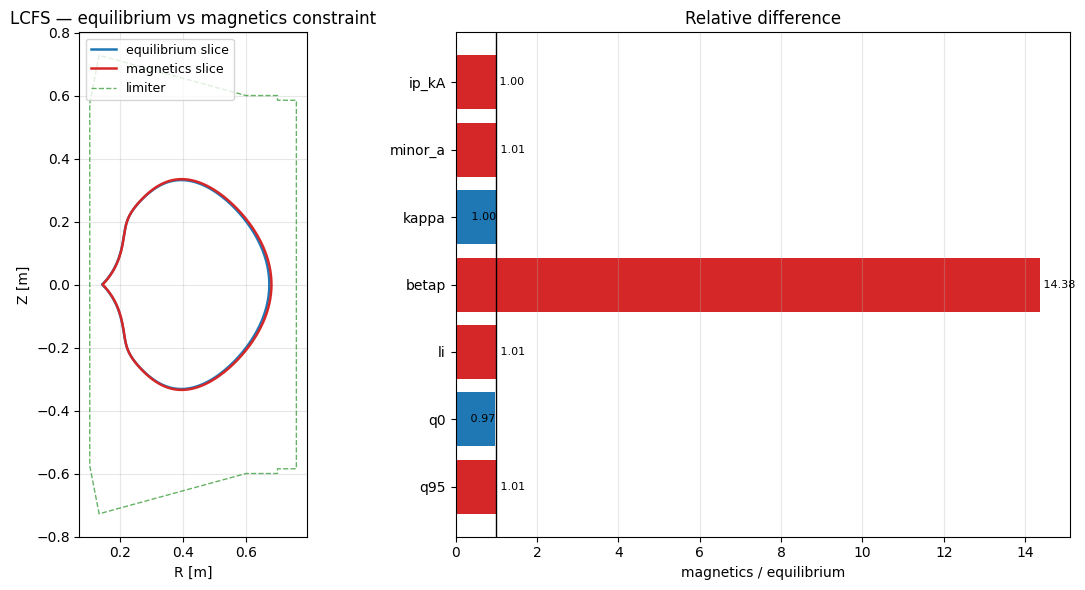

In [8]:
keys = ["ip_kA", "minor_a", "kappa", "delta_u", "betap", "li", "q0", "q95"]

# --- side-by-side scalar table ---
hdr = f"{'scalar':<10}{'equilibrium':>14}{'magnetics':>14}{'mag - eq':>14}"
print(hdr); print("-" * len(hdr))
for k in keys:
    ve = res_eq.scalars.get(k, float("nan"))
    vm = res_mag.scalars.get(k, float("nan"))
    print(f"{k:<10}{ve:14.4f}{vm:14.4f}{vm - ve:14.4f}")

# --- figure: LCFS overlay + relative-difference bars ---
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 6),
                               gridspec_kw={"width_ratios": [1, 1.1]})
for name, res, c in [("equilibrium slice", res_eq, "tab:blue"),
                     ("magnetics slice", res_mag, "tab:red")]:
    if res.geqdsk:
        b = res.geqdsk[0]
        axL.plot(b["RBBBS"], b["ZBBBS"], color=c, lw=1.8, label=name)
b = res_eq.geqdsk[0]
axL.plot(np.r_[b["RLIM"], b["RLIM"][:1]], np.r_[b["ZLIM"], b["ZLIM"][:1]],
         "g--", lw=1, alpha=0.6, label="limiter")
axL.set_aspect("equal"); axL.set_xlabel("R [m]"); axL.set_ylabel("Z [m]")
axL.set_title("LCFS — equilibrium vs magnetics constraint")
axL.legend(fontsize=9); axL.grid(alpha=0.3)

rkeys = ["ip_kA", "minor_a", "kappa", "betap", "li", "q0", "q95"]
ratio = [res_mag.scalars.get(k, np.nan) / res_eq.scalars.get(k, np.nan) for k in rkeys]
ypos = np.arange(len(rkeys))
axR.barh(ypos, ratio, color=["tab:red" if r > 1 else "tab:blue" for r in ratio])
for y, r in zip(ypos, ratio):
    axR.text(r, y, f" {r:.2f}", va="center", ha="left" if r >= 1 else "right", fontsize=8)
axR.set_yticks(ypos); axR.set_yticklabels(rkeys)
axR.axvline(1.0, color="k", lw=1)
axR.invert_yaxis()
axR.set_xlabel("magnetics / equilibrium"); axR.set_title("Relative difference")
axR.grid(alpha=0.3, axis="x")
fig.tight_layout(); plt.show()

## 6. Equilibrium back in an ODS — 2D overview

`collect_tes_outputs` already converted the TES g-file into `result.ods`
(`equilibrium` subtree) via `vaft.data.eqdsk`. That means the standard
`vaft.plot` tools work unchanged.

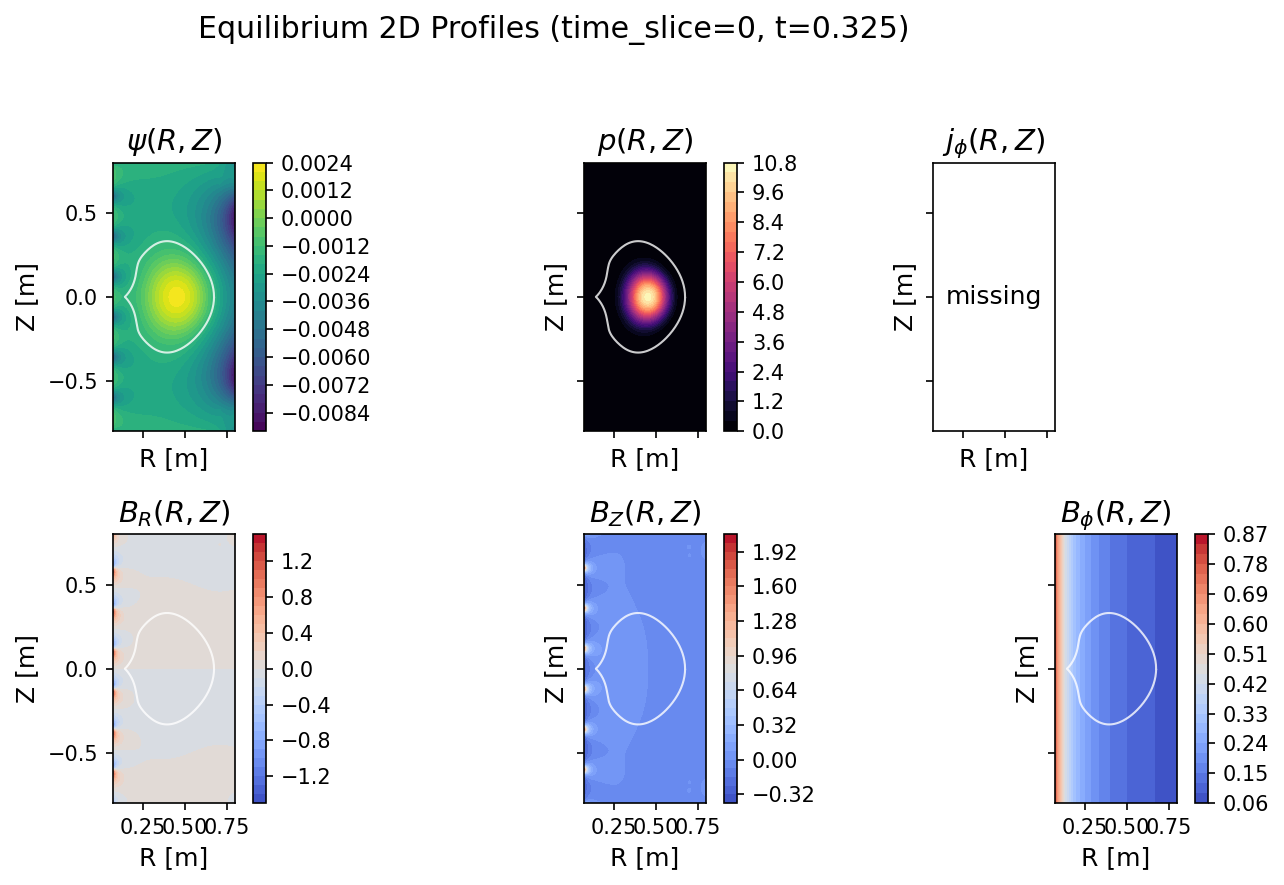

In [9]:
vaft.plot.twodim.equilibrium_2d_profiles(result.ods, time_slice=0)
plt.show()

## 7. 1D flux-function profiles

The g-file flux functions (p, q, p′, FF′) plotted against normalized poloidal flux.

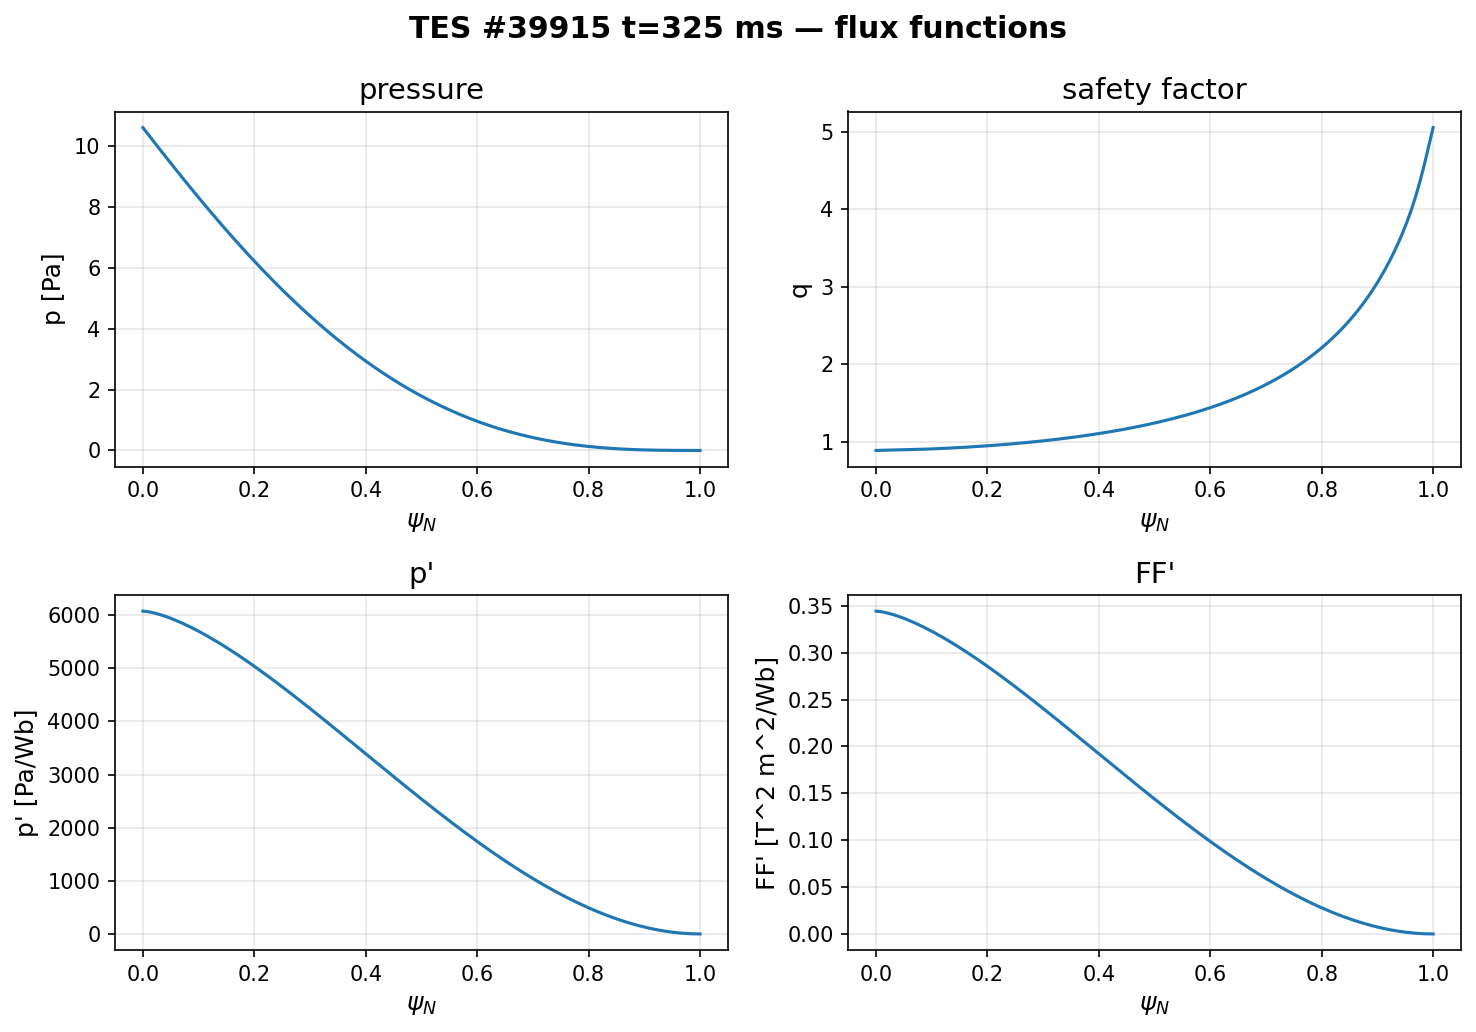

In [10]:
g = result.geqdsk[0]
psin = np.linspace(0.0, 1.0, len(g["PRES"]))
fig, ax = plt.subplots(2, 2, figsize=(10, 7))
ax[0, 0].plot(psin, g["PRES"]);   ax[0, 0].set_ylabel("p [Pa]");        ax[0, 0].set_title("pressure")
ax[0, 1].plot(psin, g["QPSI"]);   ax[0, 1].set_ylabel("q");             ax[0, 1].set_title("safety factor")
ax[1, 0].plot(psin, g["PPRIME"]); ax[1, 0].set_ylabel("p' [Pa/Wb]");   ax[1, 0].set_title("p'")
ax[1, 1].plot(psin, g["FFPRIM"]); ax[1, 1].set_ylabel("FF' [T^2 m^2/Wb]"); ax[1, 1].set_title("FF'")
for a in ax.ravel():
    a.set_xlabel(r"$\psi_N$"); a.grid(alpha=0.3)
fig.suptitle(f"TES #{SHOT} t={TIME*1e3:.0f} ms — flux functions", fontweight="bold")
fig.tight_layout(); plt.show()

## 8. External-coil set and LCFS

The coil table that was fed to TES, drawn in the poloidal plane and coloured by the
*updated* current returned in the `.RESULT` file, with the converged LCFS overlaid.

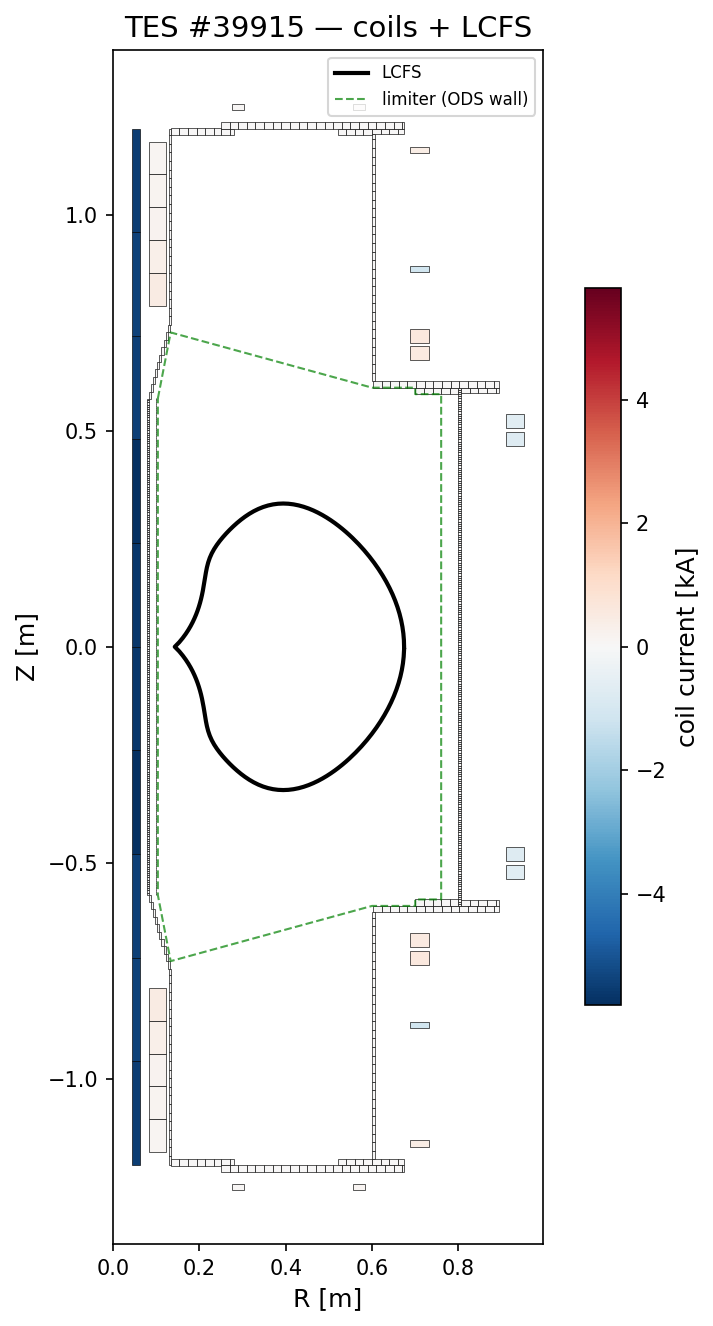

In [11]:
import re
import matplotlib.patches as mpatches
from matplotlib.colors import TwoSlopeNorm
from matplotlib.cm import ScalarMappable

# Parse the COILS block (R Z dR dZ Nturn I_kA group scale) from the C-format input.
lines = inputs.cinput.read_text().splitlines()
i0 = next(i for i, ln in enumerate(lines) if ln.startswith("NCOIL"))
ncoil = int(lines[i0].split()[1])
coils = np.array([[float(x) for x in lines[i0 + 1 + k].split()] for k in range(ncoil)])

# Use the updated currents from .RESULT when available, else the input currents.
upd = {c["index"]: c["updated_kA"] for c in result.scalars.get("coils", [])}
I = np.array([upd.get(k + 1, coils[k, 5]) for k in range(ncoil)])

bnd = result.geqdsk[0]
imax = max(np.abs(I).max(), 1e-9)
norm = TwoSlopeNorm(vmin=-imax, vcenter=0, vmax=imax)
cmap = plt.cm.RdBu_r

fig, ax = plt.subplots(figsize=(6, 9))
for k in range(ncoil):
    r, z, dr, dz = coils[k, 0], coils[k, 1], coils[k, 2], coils[k, 3]
    ax.add_patch(mpatches.Rectangle((r - dr / 2, z - dz / 2), dr, dz,
                                    facecolor=cmap(norm(I[k])), edgecolor="k", lw=0.3))
ax.plot(bnd["RBBBS"], bnd["ZBBBS"], "k-", lw=2, label="LCFS")
ax.plot(np.r_[bnd["RLIM"], bnd["RLIM"][:1]], np.r_[bnd["ZLIM"], bnd["ZLIM"][:1]],
        "g--", lw=1, alpha=0.7, label="limiter (ODS wall)")
ax.set_aspect("equal"); ax.set_xlabel("R [m]"); ax.set_ylabel("Z [m]")
ax.set_title(f"TES #{SHOT} — coils + LCFS"); ax.legend(loc="upper right", fontsize=8)
sm = ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
fig.colorbar(sm, ax=ax, shrink=0.6, label="coil current [kA]")
fig.tight_layout(); plt.show()

## 9. Plasma-current scan

`scan_tes` varies one `TESConfig` field across a list of values, running a fresh
solve in a per-value sub-directory. Here we scan the plasma current and overlay the
resulting LCFS and key scalars.

In [12]:
scan_cfg = tes.TESConfig(
    executable=RTES, workdir=WORKDIR / "scan",
    shot=SHOT, time=TIME, bt0=0.15, betap_type=1, eddy=1,
)

def _log(v, r):
    print(f"  IP={v:5.0f} kA -> ok={r.ok}  q95={r.scalars.get('q95'):.2f}  "
          f"kappa={r.scalars.get('kappa'):.3f}")

ip_values = [50, 100, 150]
scan = tes.scan_tes(ods, scan_cfg, ip_values, param="ip0_kA", on_result=_log)

  IP=   50 kA -> ok=True  q95=3.83  kappa=1.249


  IP=  100 kA -> ok=True  q95=2.55  kappa=1.313


  IP=  150 kA -> ok=True  q95=1.93  kappa=1.355


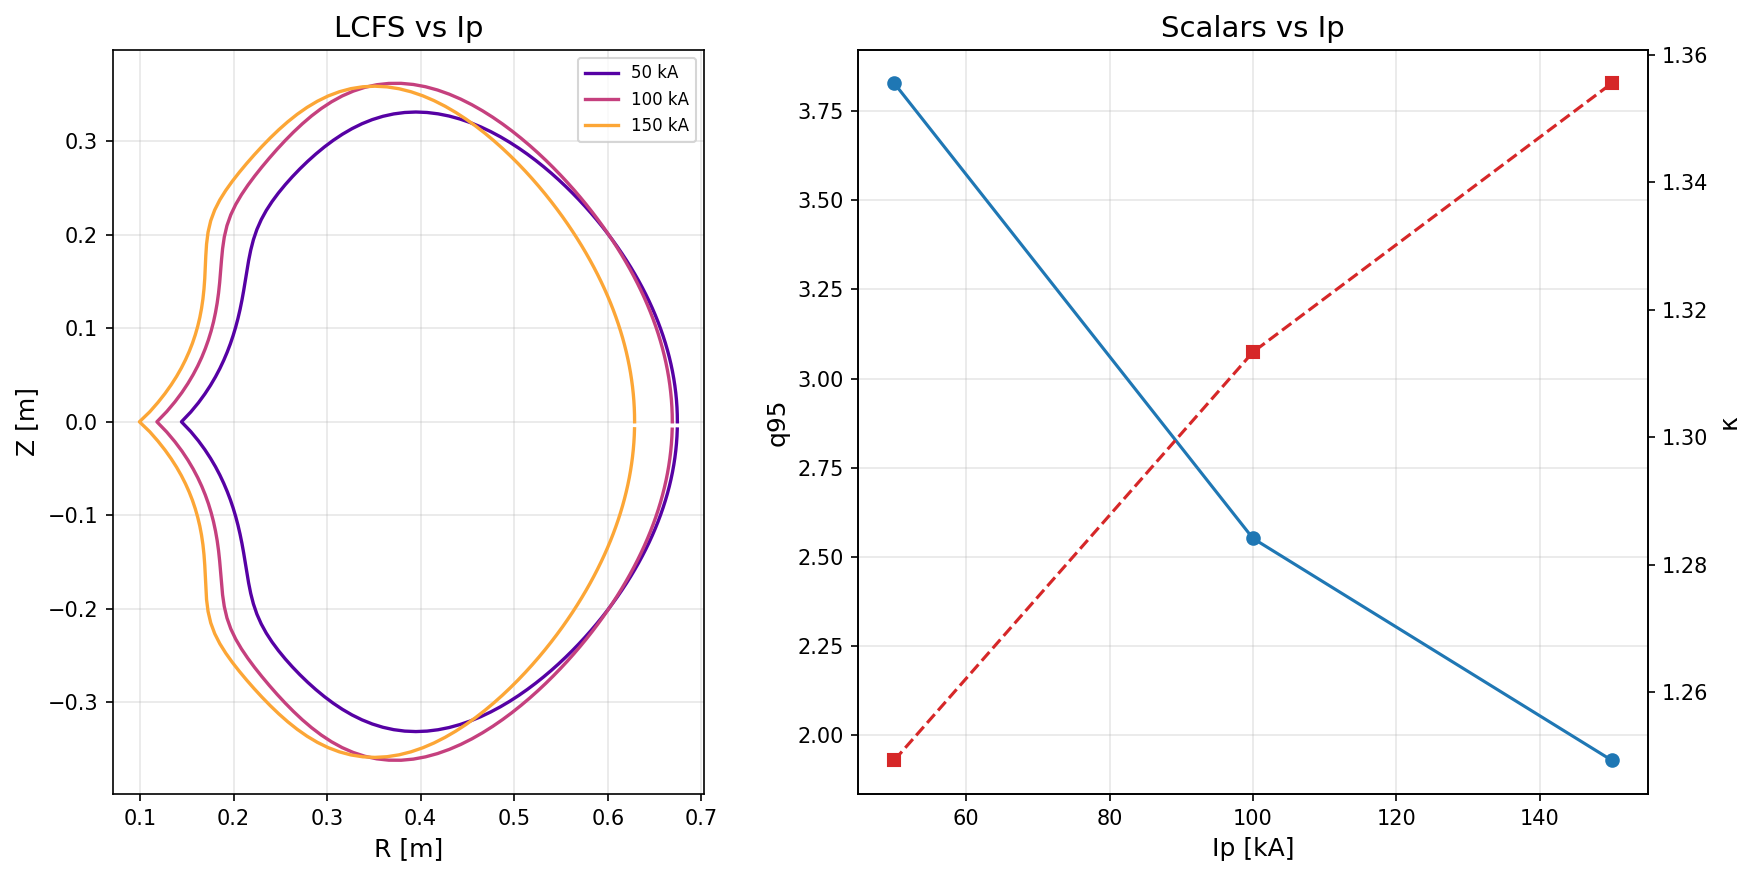

In [13]:
colors = plt.cm.plasma(np.linspace(0.15, 0.8, len(scan)))
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 6),
                               gridspec_kw={"width_ratios": [1, 1.2]})

for (v, r), c in zip(scan, colors):
    if r.geqdsk:
        b = r.geqdsk[0]
        axL.plot(b["RBBBS"], b["ZBBBS"], color=c, lw=1.6, label=f"{v:.0f} kA")
axL.set_aspect("equal"); axL.set_xlabel("R [m]"); axL.set_ylabel("Z [m]")
axL.set_title("LCFS vs Ip"); axL.legend(fontsize=8); axL.grid(alpha=0.3)

ips = [v for v, _ in scan]
q95 = [r.scalars.get("q95", np.nan) for _, r in scan]
kap = [r.scalars.get("kappa", np.nan) for _, r in scan]
axR.plot(ips, q95, "o-", label="q95")
axR.set_xlabel("Ip [kA]"); axR.set_ylabel("q95"); axR.grid(alpha=0.3)
axt = axR.twinx(); axt.plot(ips, kap, "s--", color="tab:red", label="κ"); axt.set_ylabel("κ")
axR.set_title("Scalars vs Ip")
fig.tight_layout(); plt.show()

## 10. Full-time run — equilibrium time evolution

Driving the forward solve at **every** equilibrium time slice (a `scan_tes` over
`time`) reconstructs the discharge evolution in one pass. Each point selects the
nearest equilibrium slice for its Ip/βp, exactly as in section 5.

In [14]:
eq_times = [float(t) for t in np.asarray(ods["equilibrium.time"])]
ft_cfg = tes.TESConfig(
    executable=RTES, workdir=WORKDIR / "full_time",
    shot=SHOT, constraint_source="equilibrium",
    bt0=0.15, betap_type=1, eddy=True,
)

def _log_t(t, r):
    print(f"  t={t*1e3:6.1f} ms -> ok={r.ok}  ip={r.scalars.get('ip_kA'):5.1f} kA  "
          f"kappa={r.scalars.get('kappa'):.3f}  q95={r.scalars.get('q95'):.2f}")

full = tes.scan_tes(ods, ft_cfg, eq_times, param="time", on_result=_log_t)

  t= 316.0 ms -> ok=True  ip= 80.9 kA  kappa=1.619  q95=6.01


  t= 317.0 ms -> ok=True  ip= 80.9 kA  kappa=1.391  q95=4.15


  t= 318.0 ms -> ok=True  ip= 80.2 kA  kappa=1.351  q95=3.65


  t= 319.0 ms -> ok=True  ip= 79.7 kA  kappa=1.325  q95=3.37


  t= 320.0 ms -> ok=True  ip= 79.2 kA  kappa=1.308  q95=3.18


  t= 324.0 ms -> ok=True  ip= 56.8 kA  kappa=1.256  q95=3.55


  t= 325.0 ms -> ok=True  ip= 51.5 kA  kappa=1.250  q95=3.78


  t= 327.0 ms -> ok=True  ip= 42.6 kA  kappa=1.244  q95=4.39


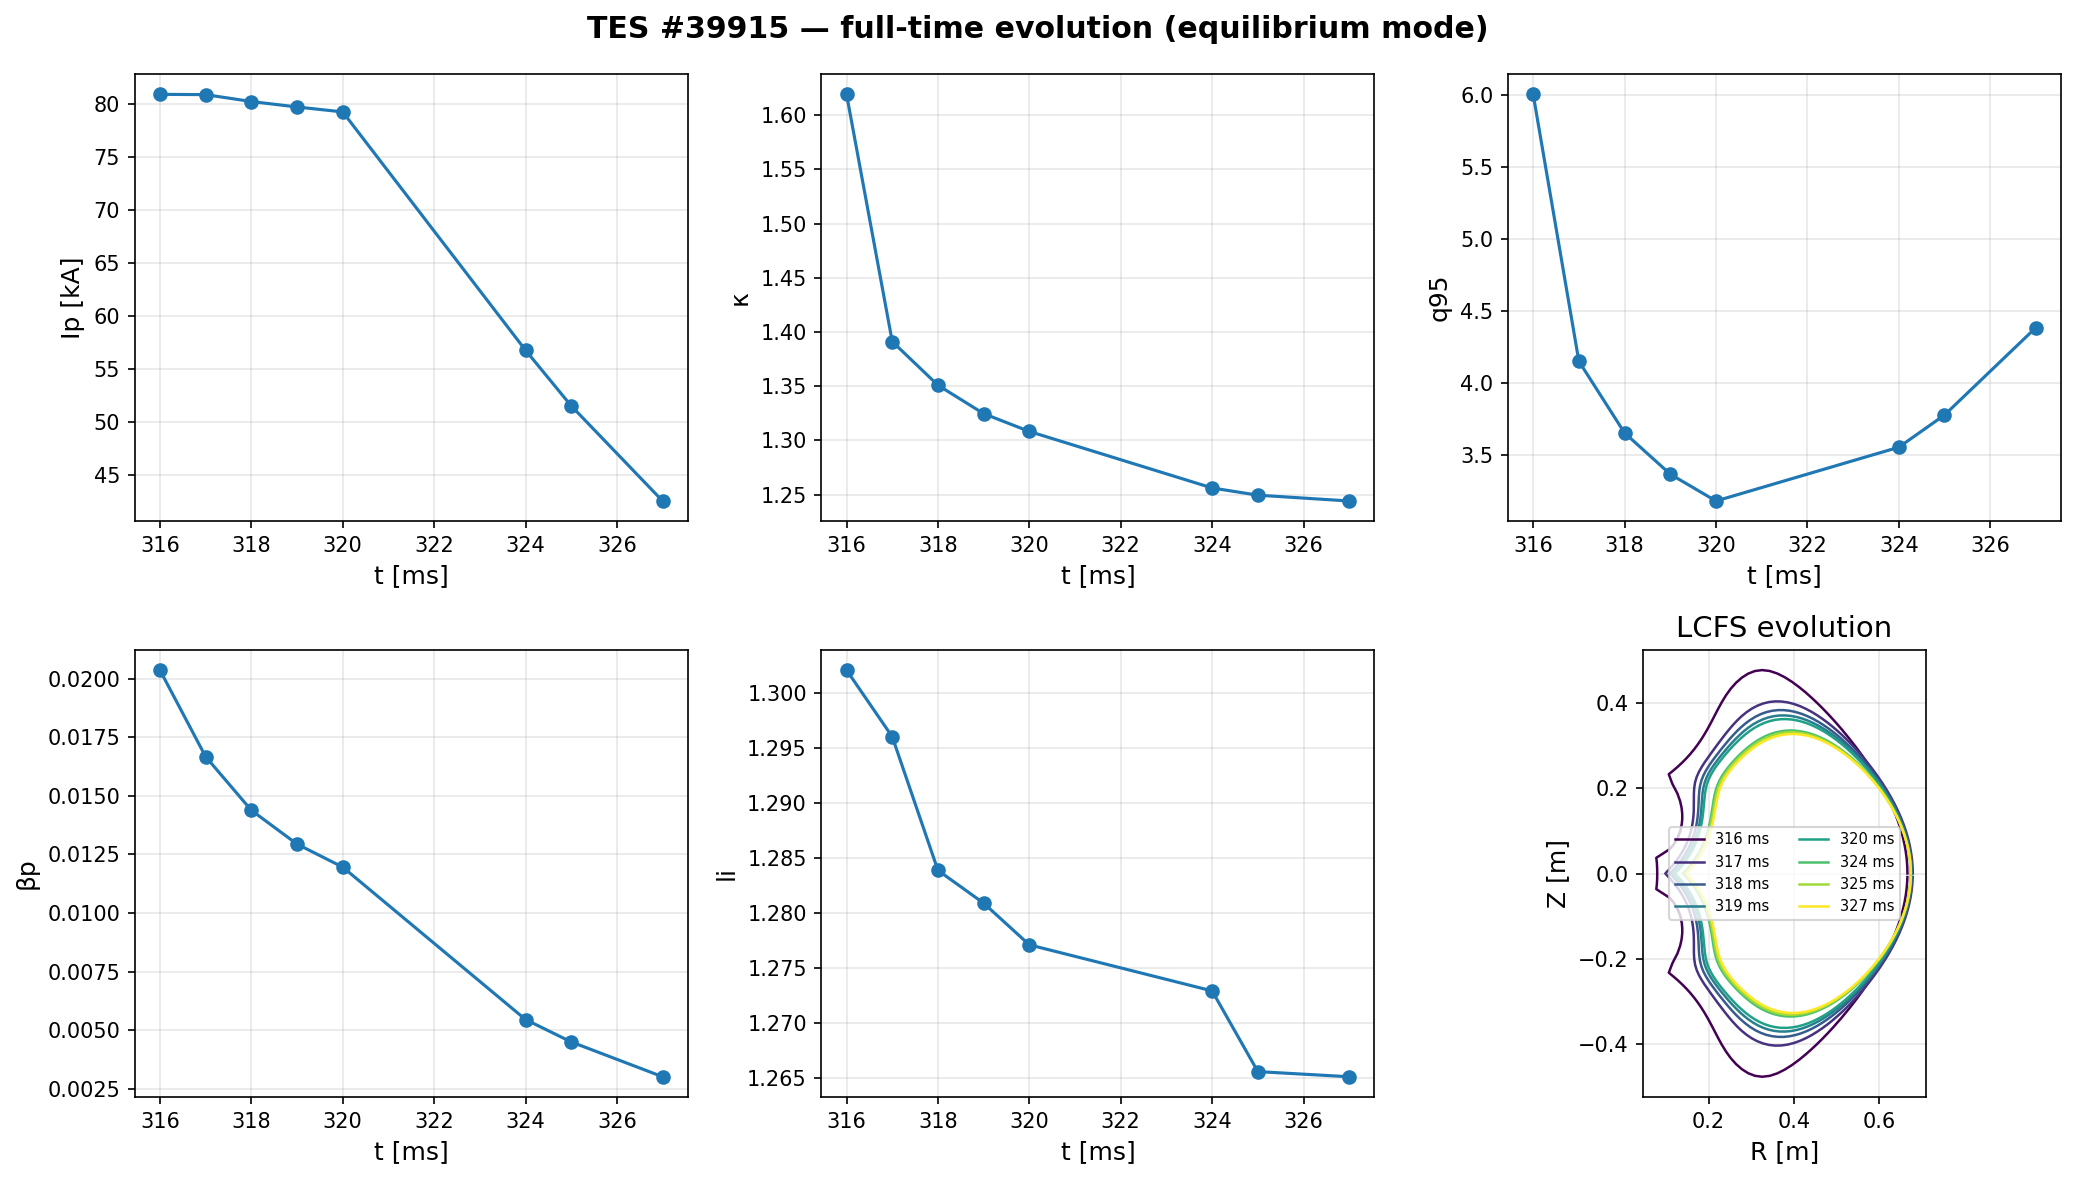

In [15]:
ts = np.array([t for t, _ in full]) * 1e3            # ms
def _tr(k):
    return np.array([r.scalars.get(k, np.nan) for _, r in full])

fig, ax = plt.subplots(2, 3, figsize=(14, 8))
for a, (k, lbl) in zip(ax.ravel()[:5],
                       [("ip_kA", "Ip [kA]"), ("kappa", "κ"), ("q95", "q95"),
                        ("betap", "βp"), ("li", "li")]):
    a.plot(ts, _tr(k), "o-"); a.set_xlabel("t [ms]"); a.set_ylabel(lbl); a.grid(alpha=0.3)

# LCFS evolution coloured by time in the 6th panel
axL = ax[1, 2]
cols = plt.cm.viridis(np.linspace(0, 1, len(full)))
for (t, r), c in zip(full, cols):
    if r.geqdsk:
        b = r.geqdsk[0]
        axL.plot(b["RBBBS"], b["ZBBBS"], color=c, lw=1.2, label=f"{t*1e3:.0f} ms")
axL.set_aspect("equal"); axL.set_xlabel("R [m]"); axL.set_ylabel("Z [m]")
axL.set_title("LCFS evolution"); axL.legend(fontsize=7, ncol=2); axL.grid(alpha=0.3)

fig.suptitle(f"TES #{SHOT} — full-time evolution (equilibrium mode)", fontweight="bold")
fig.tight_layout(); plt.show()

## Notes / open tasks
- **Limiter source.** The limiter is read from the ODS `wall` IDS and clipped to the
  computational grid. A finer first-wall can be supplied via `TESConfig.limiter=(r, z)`
  when a more detailed limiting surface is needed.
- **a-file / extra outputs.** `run_tes` also produces an a-file and the `.BNDRY`,
  `.SURF`, `.PSI`, … products; only the g-file is mapped back into the ODS so far.
  Mapping the a-file scalars into `equilibrium...global_quantities` is a follow-up.
- **1D `r_inboard`.** `vaft.plot.onedim.equilibrium_1d_radial` needs midplane
  geometry that the g-file → ODS bridge does not yet fill; the 1D plot here reads the
  g-file flux functions directly instead.